In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# CREATE SAMPLE TRANSACTION DATA (GROCERY ITEMS)
data = [
    ["Milk", "Bread", "Butter"],
    ["Bread", "Butter"],
    ["Milk", "Bread", "Butter"],
    ["Milk", "Bread"],
    ["Bread", "Butter"],
    ["Milk", "Butter"],
]

In [14]:
# INITIALIZE TRANSACTION ENCODER FOR ONE-HOT ENCODING
transaction_encoder = TransactionEncoder()

# TRANSFORM TRANSACTION DATA INTO BOOLEAN MATRIX
encoded_data = transaction_encoder.fit_transform(data)

In [15]:
# CONVERT ENCODED DATA TO DATAFRAME WITH ITEM COLUMNS
encoded_df = pd.DataFrame(encoded_data, columns=transaction_encoder.columns_)

In [16]:
# DISPLAY THE ENCODED TRANSACTION DATAFRAME
print("=>> ENCODED TRANSACTION DATAFRAME (ONE-HOT ENCODING) >>")
display(encoded_df)

=>> ENCODED TRANSACTION DATAFRAME (ONE-HOT ENCODING) >>


,Bread,Butter,Milk
0,True,True,True
1,True,True,False
2,True,True,True
3,True,False,True
4,True,True,False
5,False,True,True


In [17]:
# APPLY APRIORI ALGORITHM TO FIND FREQUENT ITEMSETS
# min_support=0.5 means itemsets must appear in at least 50% of transactions
frequent_itemsets = apriori(encoded_df, min_support=0.5, use_colnames=True)


# DISPLAY THE FREQUENT ITEMSETS
print("=>> FREQUENT ITEMSETS (min_support=0.5) >>")
display(frequent_itemsets)

=>> FREQUENT ITEMSETS (min_support=0.5) >>


,support,itemsets
0,0.833333,frozenset({Bread})
1,0.833333,frozenset({Butter})
2,0.666667,frozenset({Milk})
3,0.666667,"frozenset({Butter, Bread})"
4,0.500000,"frozenset({Milk, Bread})"
5,0.500000,"frozenset({Butter, Milk})"


In [18]:
# GENERATE ASSOCIATION RULES FROM FREQUENT ITEMSETS
# metric="confidence", min_threshold=0.6 means rules must have at least 60% confidence
association_rules_df = association_rules(
    frequent_itemsets, metric="confidence", min_threshold=0.6
)


# DISPLAY THE ASSOCIATION RULES
print("=>> ASSOCIATION RULES (confidence >= 0.6) >>")
display(association_rules_df)

=>> ASSOCIATION RULES (confidence >= 0.6) >>


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Butter}),frozenset({Bread}),0.833333,0.833333,0.666667,0.80,0.96,1.0,-0.027778,0.833333,-0.20,0.666667,-0.2,0.800
1,frozenset({Bread}),frozenset({Butter}),0.833333,0.833333,0.666667,0.80,0.96,1.0,-0.027778,0.833333,-0.20,0.666667,-0.2,0.800
2,frozenset({Milk}),frozenset({Bread}),0.666667,0.833333,0.500000,0.75,0.90,1.0,-0.055556,0.666667,-0.25,0.500000,-0.5,0.675
3,frozenset({Bread}),frozenset({Milk}),0.833333,0.666667,0.500000,0.60,0.90,1.0,-0.055556,0.833333,-0.40,0.500000,-0.2,0.675
4,frozenset({Butter}),frozenset({Milk}),0.833333,0.666667,0.500000,0.60,0.90,1.0,-0.055556,0.833333,-0.40,0.500000,-0.2,0.675
5,frozenset({Milk}),frozenset({Butter}),0.666667,0.833333,0.500000,0.75,0.90,1.0,-0.055556,0.666667,-0.25,0.500000,-0.5,0.675


In [19]:
# CONVERT ITEMSETS FROM TUPLE TO STRING FOR BETTER VISUALIZATION
frequent_itemsets["itemsets"] = frequent_itemsets["itemsets"].apply(
    lambda x: "".join(list(x))  # JOIN ITEMS WITH " + " FOR READABILITY
)

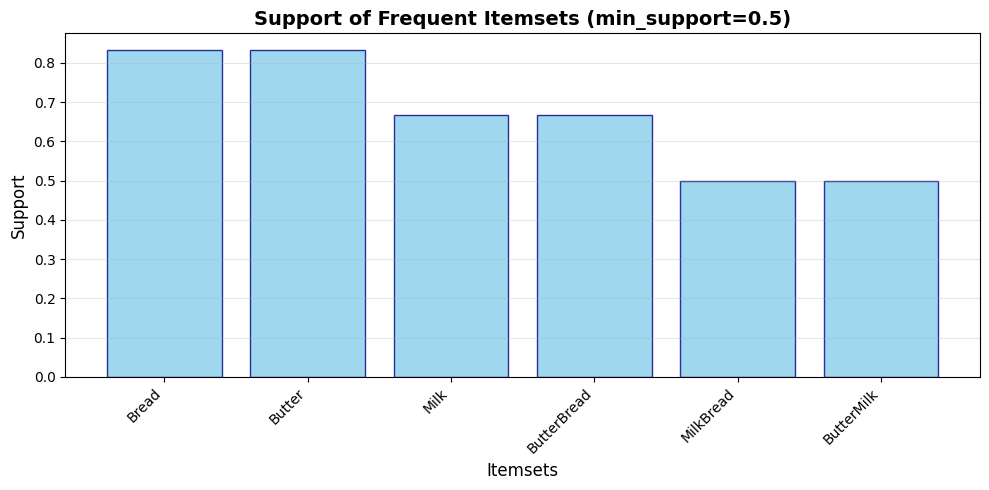

In [20]:
# VISUALIZE SUPPORT OF FREQUENT ITEMSETS
plt.figure(figsize=(10, 5))
plt.bar(
    frequent_itemsets["itemsets"],
    frequent_itemsets["support"],
    color="skyblue",
    edgecolor="navy",
    alpha=0.8,
)
plt.title(
    "Support of Frequent Itemsets (min_support=0.5)", fontsize=14, fontweight="bold"
)
plt.xlabel("Itemsets", fontsize=12)
plt.ylabel("Support", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# DISPLAY SUMMARY STATISTICS
print("=>> ASSOCIATION RULES SUMMARY >>")
print("=" * 35)
print(f":> Total Rules Generated: {len(association_rules_df)}")

if len(association_rules_df) > 0:
    print(f":> Average Confidence: {association_rules_df['confidence'].mean():.3f}")
    print(f":> Max Confidence: {association_rules_df['confidence'].max():.3f}")
    print(f":> Average Lift: {association_rules_df['lift'].mean():.3f}")
print("=" * 35)

=>> ASSOCIATION RULES SUMMARY >>
:> Total Rules Generated: 6
:> Average Confidence: 0.717
:> Max Confidence: 0.800
:> Average Lift: 0.920


In [22]:
# DISPLAY TOP RULES BY LIFT (MOST INTERESTING RULES)
if len(association_rules_df) > 0:
    print("=>> TOP 3 RULES BY LIFT >>")
    top_rules = association_rules_df.nlargest(3, "lift")[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ]
    display(top_rules)

=>> TOP 3 RULES BY LIFT >>


,antecedents,consequents,support,confidence,lift
0,frozenset({Butter}),frozenset({Bread}),0.666667,0.8,0.96
1,frozenset({Bread}),frozenset({Butter}),0.666667,0.8,0.96
3,frozenset({Bread}),frozenset({Milk}),0.500000,0.6,0.90
